# Task 6 — House Price Prediction

## Problem Statement

House prices depend on many factors such as area, number of bedrooms, bathrooms, floors, and location.

Accurate prediction of house prices helps buyers, sellers, and real estate companies make better decisions.

This project aims to build a machine learning model to predict house prices using important property features.

## Objective

The objective of this task is to perform data preprocessing, exploratory data analysis (EDA), regression model training, and evaluation using metrics such as Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

We will also visualize predicted prices compared to actual prices.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [13]:
df = pd.read_csv("data.csv")

df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [14]:
print("Shape of dataset:", df.shape)

Shape of dataset: (4600, 18)


In [15]:
print("Column Names:")
print(df.columns)

Column Names:
Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='str')


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   str    
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   str    
 15  city           4600 non-null   str    
 16  statezip       4600 non-null   str    
 17  country        4600 non-null   str    
dtypes: float64(4), int6

In [17]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


In [18]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64


# Exploratory Data Analysis (EDA)

EDA helps us understand relationships between features and house prices before training the regression model.

We will visualize:
- Price distribution
- Correlation between features
- Bedrooms vs Price
- Area vs Price

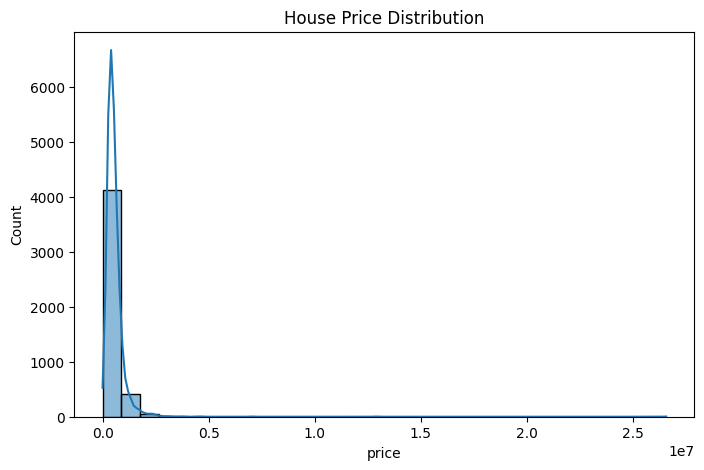

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=30, kde=True)

plt.title("House Price Distribution")
plt.show()

## Price Distribution

This histogram helps us understand how house prices are distributed and whether the dataset contains extreme values or skewness.

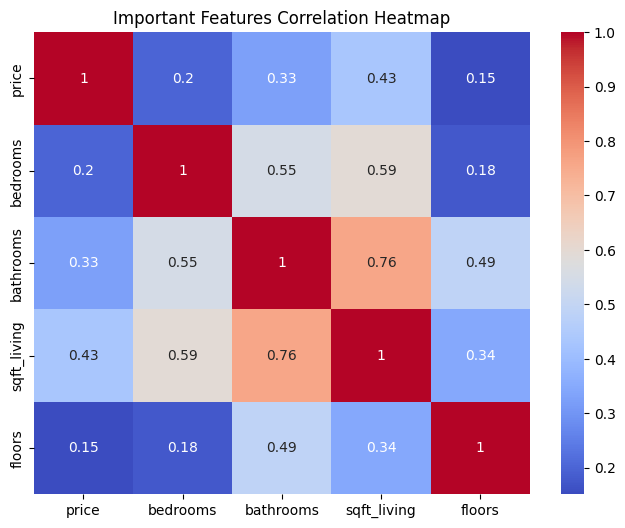

In [23]:
important_features = df[
    ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'floors']
]

plt.figure(figsize=(8,6))

sns.heatmap(
    important_features.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Important Features Correlation Heatmap")
plt.show()

## Correlation Heatmap

The heatmap shows relationships between features and helps identify the most important predictors of house prices.

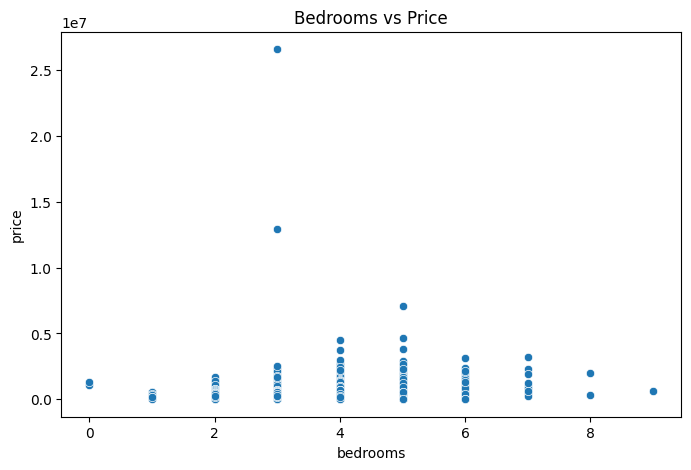

In [25]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='bedrooms', y='price', data=df)

plt.title("Bedrooms vs Price")
plt.show()

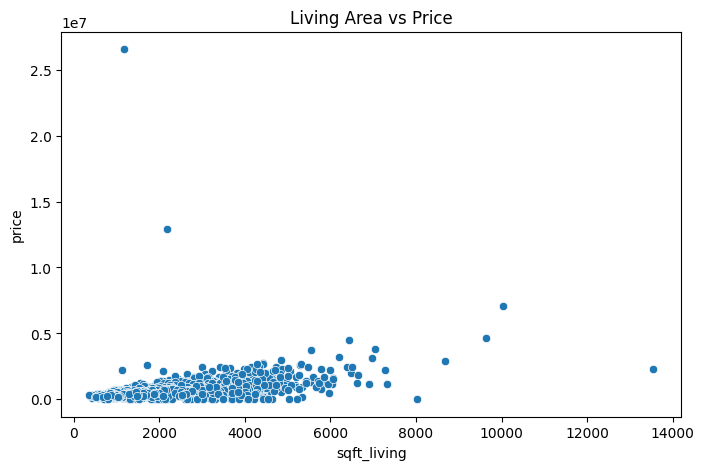

In [26]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='sqft_living', y='price', data=df)

plt.title("Living Area vs Price")
plt.show()

## Bedrooms and Area Analysis

The number of bedrooms and living area are strong indicators of house price. These plots help us observe their relationship with price.

In [27]:
features = ['bedrooms', 'bathrooms', 'sqft_living', 'floors']

X = df[features]
y = df['price']

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [29]:
model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [30]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)

Mean Absolute Error (MAE): 223831.69595289152


In [31]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Root Mean Squared Error (RMSE):", rmse)

Root Mean Squared Error (RMSE): 995819.8789168443


## Model Evaluation

MAE measures the average prediction error.

RMSE gives higher importance to larger errors and helps evaluate model performance more strictly.

Lower MAE and RMSE indicate better prediction accuracy.

In [33]:
comparison = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': y_pred
})

comparison.head()

,Actual Price,Predicted Price
3683,544000.0,366264.370376
4411,0.0,397744.522533
2584,1712500.0,823880.596490
69,365000.0,578757.530282
1844,275000.0,432565.036562


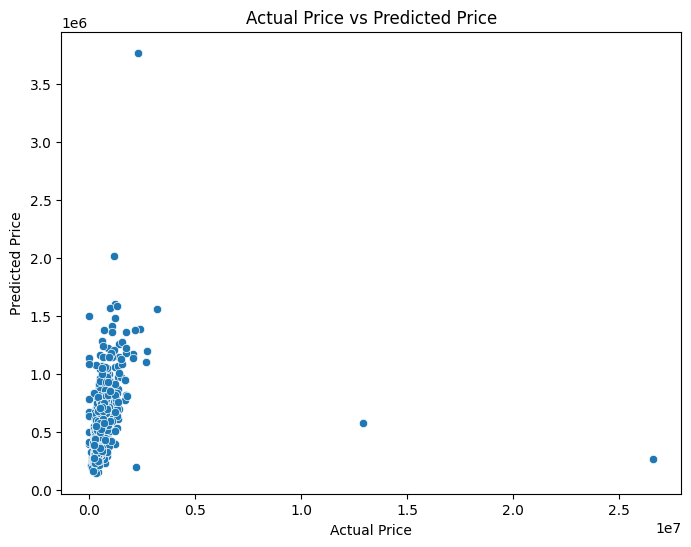

In [34]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_test,
    y=y_pred
)

plt.title("Actual Price vs Predicted Price")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

## Actual vs Predicted Prices

This plot helps compare the model’s predicted prices with actual house prices.

If points are close to a straight line, it indicates better model performance.

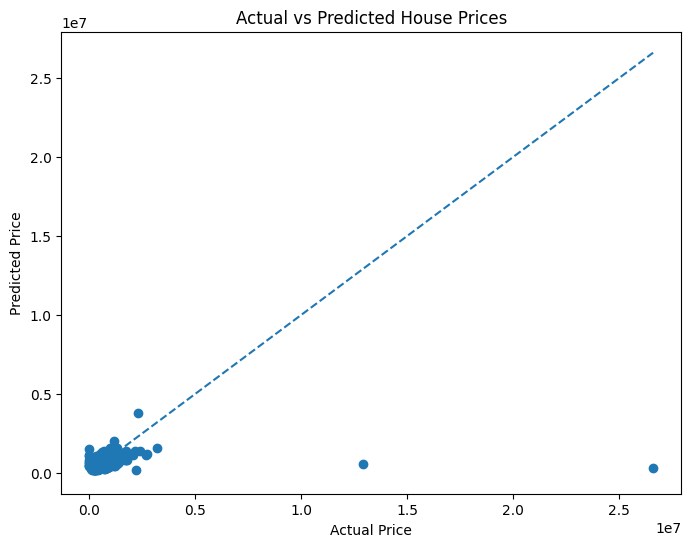

In [35]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.title("Actual vs Predicted House Prices")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

# Final Insights

1. Linear Regression successfully predicted house prices using important property features.
2. Features like living area, bathrooms, and number of bedrooms showed strong influence on price.
3. MAE and RMSE helped evaluate prediction accuracy effectively.
4. The Actual vs Predicted plot showed reasonable model performance.

# Conclusion

This project successfully built a house price prediction model using Linear Regression.

The dataset was cleaned, explored, and analyzed using EDA techniques. Feature selection and regression modeling were performed to predict property prices.

Evaluation using MAE and RMSE showed reliable performance, and visualization confirmed the effectiveness of the model.

This project demonstrates practical machine learning applications in real estate analytics.